In [1]:
# Pandas is used to work with tables (DataFrames)
import pandas as pd

# NumPy is used for numerical operations and handling missing values
import numpy as np

# Matplotlib is used to create graphs
import matplotlib.pyplot as plt

In [2]:
# Each row represents one student.
# Batch = Graduation Year (Vintage)
# Placement_Month = Number of months after graduation when the student got placed.
# NaN means the student is still not placed.

data = {
    "Student_ID": range(1,31),

    "Batch":[
        "2022","2022","2022","2022","2022",
        "2022","2022","2022","2022","2022",

        "2023","2023","2023","2023","2023",
        "2023","2023","2023","2023","2023",

        "2024","2024","2024","2024","2024",
        "2024","2024","2024","2024","2024"
    ],

    "Placement_Month":[
        1,1,2,2,3,3,4,5,6,8,
        1,2,2,3,4,5,6,7,9,12,
        2,3,4,5,6,7,9,10,12,np.nan
    ]
}

In [3]:
# Convert the dictionary into a table (DataFrame)

df = pd.DataFrame(data)

# Display the dataset
print(df)

    Student_ID Batch  Placement_Month
0            1  2022              1.0
1            2  2022              1.0
2            3  2022              2.0
3            4  2022              2.0
4            5  2022              3.0
5            6  2022              3.0
6            7  2022              4.0
7            8  2022              5.0
8            9  2022              6.0
9           10  2022              8.0
10          11  2023              1.0
11          12  2023              2.0
12          13  2023              2.0
13          14  2023              3.0
14          15  2023              4.0
15          16  2023              5.0
16          17  2023              6.0
17          18  2023              7.0
18          19  2023              9.0
19          20  2023             12.0
20          21  2024              2.0
21          22  2024              3.0
22          23  2024              4.0
23          24  2024              5.0
24          25  2024              6.0
25          

In [4]:
# Create a new column:
# 1 = Student is placed
# 0 = Student is still not placed

df["Placed"] = np.where(df["Placement_Month"].isna(), 0, 1)

# Display updated dataset
print(df)

    Student_ID Batch  Placement_Month  Placed
0            1  2022              1.0       1
1            2  2022              1.0       1
2            3  2022              2.0       1
3            4  2022              2.0       1
4            5  2022              3.0       1
5            6  2022              3.0       1
6            7  2022              4.0       1
7            8  2022              5.0       1
8            9  2022              6.0       1
9           10  2022              8.0       1
10          11  2023              1.0       1
11          12  2023              2.0       1
12          13  2023              2.0       1
13          14  2023              3.0       1
14          15  2023              4.0       1
15          16  2023              5.0       1
16          17  2023              6.0       1
17          18  2023              7.0       1
18          19  2023              9.0       1
19          20  2023             12.0       1
20          21  2024              

In [5]:
# We want to track placements for 12 months

max_month = 12

# Create an empty dataframe to store Vintage Analysis results

vintage_table = pd.DataFrame()
display(vintage_table)

""


In [6]:
# ==========================================
# Vintage Analysis
# ==========================================

# We want to track placements for 12 months
max_month = 12

# Empty DataFrame to store the results
vintage_table = pd.DataFrame()

# Loop through each batch (Vintage)
for batch in df["Batch"].unique():

    # Filter students belonging to the current batch
    temp = df[df["Batch"] == batch]

    # Total students in that batch
    total_students = len(temp)

    # List to store cumulative placement percentages
    cumulative = []

    # Loop through each month
    for month in range(1, max_month + 1):

        # Count students placed on or before the current month
        placed = temp[
            (temp["Placement_Month"] <= month) &
            (temp["Placed"] == 1)
        ].shape[0]

        # Calculate cumulative placement percentage
        placement_percentage = round((placed / total_students) * 100, 1)

        # Store the percentage
        cumulative.append(placement_percentage)

    # Save this batch as a separate column
    vintage_table[batch] = cumulative

# Set the row labels
vintage_table.index = range(1, max_month + 1)
vintage_table.index.name = "Months After Graduation"

# Display the final Vintage Analysis table
print(vintage_table)

                          2022   2023  2024
Months After Graduation                    
1                         20.0   10.0   0.0
2                         40.0   30.0  10.0
3                         60.0   40.0  20.0
4                         70.0   50.0  30.0
5                         80.0   60.0  40.0
6                         90.0   70.0  50.0
7                         90.0   80.0  60.0
8                        100.0   80.0  60.0
9                        100.0   90.0  70.0
10                       100.0   90.0  80.0
11                       100.0   90.0  80.0
12                       100.0  100.0  90.0


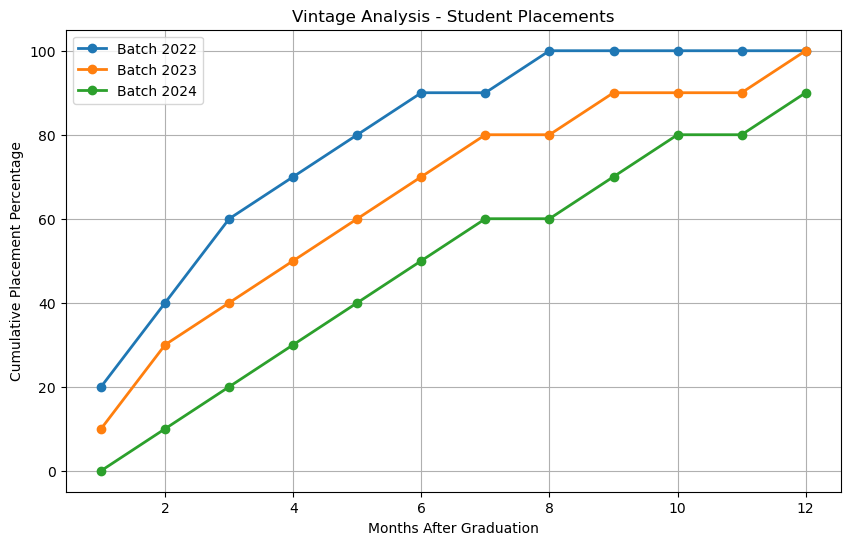

In [7]:
# Create a graph

plt.figure(figsize=(10,6))

# Draw one line for each batch

for col in vintage_table.columns:

    plt.plot(
        vintage_table.index,
        vintage_table[col],
        marker='o',
        linewidth=2,
        label=f'Batch {col}'
    )

# Add chart title

plt.title("Vintage Analysis - Student Placements")

# Label X-axis

plt.xlabel("Months After Graduation")

# Label Y-axis

plt.ylabel("Cumulative Placement Percentage")

# Add grid

plt.grid(True)

# Show legend

plt.legend()

# Display the graph

plt.show()

In [8]:
# Color the table
# Darker Green = Higher Placement Percentage

styled = vintage_table.style.background_gradient(cmap="Greens")

styled

,2022,2023,2024
Months After Graduation,,,
1,20.000000,10.000000,0.000000
2,40.000000,30.000000,10.000000
3,60.000000,40.000000,20.000000
4,70.000000,50.000000,30.000000
5,80.000000,60.000000,40.000000
6,90.000000,70.000000,50.000000
7,90.000000,80.000000,60.000000
8,100.000000,80.000000,60.000000
9,100.000000,90.000000,70.000000
